## CS310 Natural Language Processing
## Lab 3: Data preparation for implementing word2vec

In this lab, we will practice the necessary steps for implementing the `word2vec` model with `skipgram` architecture and using negative sampling for training. 

In [1]:
from typing import List
from pprint import pprint
from utils import CorpusReader
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

In [2]:
# We set min_count=1 to include all words in the corpus

corpus = CorpusReader(inputFileName="lunyu_20chapters.txt", min_count=1, lang="zh")
# corpus = CorpusReader(inputFileName="shakespeare.txt", min_count=3, lang="en")
# corpus = CorpusReader(inputFileName="ptb.train.txt", min_count=5, lang="en")

Total vocabulary: 1352


In [3]:
print(corpus.word2id["子"])
print(corpus.id2word[1])
print(len(corpus.id2word))
print(corpus.vocab_size)

# print(corpus.word2id["man"])
# print(corpus.word2id["woman"])
# print(corpus.word2id["king"])
# print(corpus.word2id["queen"])
# print(corpus.word2id["brother"])
# print(corpus.word2id["sister"])
# print(corpus.word2id["husband"])
# print(corpus.word2id["wife"])

1
子
1352
1352


### Efficient way for negative sampling

In `utils.CorpusReader` class, we have implemented a method `initTableNegatives`. It creates a list of words (`self.negatives`) with a size of 1e8. The purpose is to have a large value so that it scales up to very large corpus. 

The list contains the integer index (word ID) of each word in the vocabulary, whose probability is proportional to the power of 0.75 of the word's original frequency count. 



In [4]:
# This is a simulation of how initTableNegatives works
# The implementation in utils.py is a bit different, but the idea is the same
word_frequency = {"a": 1, "b": 2, "c": 3, "d": 4}

# the scaled sum of frequencies Z = 1**0.75 + 2**0.75 + 3**0.75 + 4**0.75 = 7.7897270
# then the scaled probability of a = 1**0.75 / Z = 0.12837420128374202
# the scaled probability of b = 2**0.75 / Z = 0.21589881215898812
# the scaled probability of c = 3**0.75 / Z = 0.29262990292629903
# the scaled probability of d = 4**0.75 / Z = 0.3630970836309708

def initTableNegatives():
    pow_frequency = np.array(list(word_frequency.values())) ** 0.75
    words_pow = sum(pow_frequency)
    ratio = pow_frequency / words_pow
    count = np.round(ratio * CorpusReader.NEGATIVE_TABLE_SIZE)
    negatives = []
    for wid, c in enumerate(count):
        negatives += [wid] * int(c)
    negatives = np.array(negatives)
    np.random.shuffle(negatives)
    return negatives

negatives = initTableNegatives()

In [5]:
print(len(negatives))
print(set(negatives)) # the word indices: a -> 0, b -> 1, c -> 2, d -> 3
print(np.sum(negatives == 0) / len(negatives)) # should be the scaled probability of a
print(np.sum(negatives == 1) / len(negatives)) # should be the scaled probability of b
print(np.sum(negatives == 2) / len(negatives)) # should be the scaled probability of c
print(np.sum(negatives == 3) / len(negatives)) # should be the scaled probability of d

99999999
{np.int64(0), np.int64(1), np.int64(2), np.int64(3)}
0.12837420128374202
0.21589881215898812
0.29262990292629903
0.3630970836309708


Next, the `getNegatives` method returns the negative samples for a target word. The idea is to chop off a segment of given `size` from the `negatives` list. 

If the segment contains the target word, it is discarded and a new segment is taken. This is done to avoid the target word itself to be sampled as a negative.

In [6]:
# Test some examples
corpus.getNegatives(target=1, size=5)

array([ 10,  80,   6,  10, 170])

## T1. Generate data for training

Now we are going to implement the sliding window to generate center, outside, and negative words for each position in a sentence.

- It takes a list of words as input and go through each word as a center word.
- For each center word, both the left and right `window_size` words are considered as outside words. This number is smaller near the two ends of the sentence.
- Call `corpus.getNegatives` to get negative samples for each center word.

In [9]:
def generate_data(words: List[str], window_size: int, k: int, corpus: CorpusReader):
    """ Generate the training data for word2vec skip-gram model
    Args:
        text: the input text
        window_size: the size of the context window
        k: the number of negative samples
        corpus: the corpus object, providing utilities such as word2id, getNegatives, etc.
    """
    ### START YOUR CODE ###
    word_ids = [corpus.word2id[word] for word in words]  # convert words to ids

    for center_idx, center_id in enumerate(word_ids):
        left = max(0, center_idx - window_size)
        right = min(len(word_ids), center_idx + window_size + 1)

        for outside_idx in range(left, right):
            if outside_idx == center_idx:
                continue
            outside_id = word_ids[outside_idx]
            negatives = corpus.getNegatives(target=center_id, size=k)
            yield center_id, outside_id, negatives
    ### END YOUR CODE ###

In [10]:
# Test generate_data
text = "学而时习之"
words = list(text)
print('words:', words)
print('word ids:', [corpus.word2id[word] for word in words])

# first center word is 学
print()
print(f'When window size is 3, for center word 学 -> {corpus.word2id["学"]}')
print(f'the outside words are: ')
print(f'而 -> {corpus.word2id["而"]}')
print(f'时 -> {corpus.word2id["时"]}')
print(f'习 -> {corpus.word2id["习"]}')

print()
print('output from generate_data:')
data = list(generate_data(list(text), window_size=3, k=5, corpus=corpus))
pprint(data[:3])


### You are expected to see the following output:
### Note that the negative samples are random, so you may see different numbers
# words: ['学', '而', '时', '习', '之']
# word ids: [46, 8, 224, 544, 5]

# When window size is 3, for center word 学 -> 46
# the outside words are: 
# 而 -> 8
# 时 -> 224
# 习 -> 544

# output from generate_data:
# [(46, 8, array([354,   3, 831, 570,  27])),
#  (46, 224, array([1077, 1095,   89,  340,   92])),
#  (46, 544, array([ 49, 488,   4, 269,  30]))]

words: ['学', '而', '时', '习', '之']
word ids: [46, 8, 224, 544, 5]

When window size is 3, for center word 学 -> 46
the outside words are: 
而 -> 8
时 -> 224
习 -> 544

output from generate_data:
[(46, 8, array([406,   4, 192, 744, 407])),
 (46, 224, array([  42, 1278,    6,    5,    7])),
 (46, 544, array([ 14,   1, 102, 611,  12]))]


The above data are not in batch yet. We want all center words are batched into a tensor of dimension `batch_size`; same for the outside words and negative samples.

For example, in "学而时习之", assume we use `batch_size=4`, then the returned batch[0] will contain three tensors. 
- The first tensor contains center words, i.e.,  ["学", "学", "学"] $\bigoplus$ ["而"] => [46, 46, 46, 8]
- The second tensor contains the correponding outside words, i.e., "而", "时", and "习" are outside words for "学"; "学" is the outside word for "而"; therfore the tensor is ["而", "时", "习"] $\bigoplus$ ["学"] => [8, 224, 544,  46]
- The third tensor contains the negative samples, whose dimension is `batch_size` $\times$ `k`
  
The data type of the tensors is `torch.long`.

In [12]:
def batchify(data: List, batch_size: int):
    """ Group a stream into batches and yield them as torch tensors.
    Args:
        data: a list of tuples
        batch_size: the batch size 
    Yields:
        a tuple of three torch tensors: center, outside, negative
    """
    assert batch_size < len(data) # data should be long enough
    for i in range(0, len(data), batch_size):
        batch = data[i:i + batch_size]
        if i > len(data) - batch_size: # if the last batch is smaller than batch_size, pad it with the first few data
            batch = batch + data[:i + batch_size - len(data)]
        
        ### START YOUR CODE ###
        center = torch.tensor([item[0] for item in batch], dtype=torch.long)
        outside = torch.tensor([item[1] for item in batch], dtype=torch.long)
        negative = torch.tensor(np.array([item[2] for item in batch]), dtype=torch.long)
        yield center, outside, negative
        ### END YOUR CODE ###
        

In [13]:
# Test batchify

text = "学而时习之"
words = list(text)
data = list(generate_data(words, window_size=3, k=5, corpus=corpus))

batches = list(batchify(data, batch_size=4))
print(batches[0])

### You are expected to see the following output:
### Note that the negative samples are random, so you may see different numbers
# (tensor([46, 46, 46,  8]), tensor([  8, 224, 544,  46]), 
#  tensor([[  85,    3,   72,   26,   35],
#         [   7,    1,  487,   20,    4],
#         [  12,  227,    2,   25,  639],
#         [ 582,  148,   15, 1203,   85]]))

(tensor([46, 46, 46,  8]), tensor([  8, 224, 544,  46]), tensor([[  64,  333,  872,   99,   10],
        [   1,  231,   67,  110,  381],
        [  58,   26, 1340,   30,    3],
        [  31, 1315,   23,    2,  792]]))


## T2. Implement the SkipGram class

`SkipGram` is a subclass of `nn.Module`. The two key components are:
- `__init__`: initialize the embeddings
  - Two `nn.Embedding` objects are created: `self.emb_v` for center words; `self.emb_u` for outside words and negative samples.
  - Each `nn.Embedding` is created with `vocab_size` and `emb_dim` as input arguments. 
  - `self.emb_v` is initialized with uniform distribution; `self.emb_u` is initialized with zeros.
- `forward`: given input tensors, return the loss of the model
  - Takes three tensors as input: center words, outside words, and negative samples. They are the output from the previously defined `batchify` function.
  - Compute the loss using the formula: $-\log\sigma(v_c \cdot u_o) - \sum_{k=1}^K \log\sigma(-v_c \cdot u_k)$

*Hint*:
- For the $\log\sigma$ function, you can use `F.logsigmoid` in PyTorch. See the imported module: `import torch.nn.functional as F`
- If the input to `F.logsigmoid` is too large, it will return 0, which is not good for training. You can use `torch.clamp` to limit the input to a certain range. For example, `torch.clamp(x, min=-10, max=10)` will limit the input to be in the range of $[-10, 10]$.

In [14]:
class SkipGram(nn.Module):
    def __init__(self, vocab_size, emb_size):
        super(SkipGram, self).__init__()
        self.vocab_size = vocab_size
        self.emb_size = emb_size
        self.emb_v = nn.Embedding(vocab_size, emb_size, sparse=True)
        self.emb_u = nn.Embedding(vocab_size, emb_size, sparse=True)

        initrange = 1.0 / self.emb_size # some experience passed down from generation to generation
        nn.init.uniform_(self.emb_v.weight.data, -initrange, initrange) # same outcome as self.emb_v.weight.data.uniform_(-initrange, initrange)
        nn.init.constant_(self.emb_u.weight.data, 0) # same outcome as self.emb_u.weight.data.zero_()

    def forward(self, center, outside, negative):
        """
        Args:
            center: the center word indices (B, )
            outside: the outside word indices (B, )
            negative: the negative word indices (B, k)
        """
        v_c = self.emb_v(center)
        u_o = self.emb_u(outside)
        u_n = self.emb_u(negative)
        
        ### START YOUR CODE ###
        positive_score = torch.sum(v_c * u_o, dim=1)  # (B,)
        positive_score = torch.clamp(positive_score, min=-10, max=10)

        negative_score = torch.bmm(u_n, v_c.unsqueeze(2)).squeeze(2)  # (B, k)
        negative_score = torch.clamp(negative_score, min=-10, max=10)

        loss = -F.logsigmoid(positive_score) - torch.sum(F.logsigmoid(-negative_score), dim=1)
        ### END YOUR CODE ###

        return loss
    
    def save_embedding(self, id2word, file_name):
        embedding = self.emb_v.weight.cpu().data.numpy()
        with open(file_name, 'w') as f:
            f.write('%d %d\n' % (len(id2word), self.emb_size))
            for wid, w in id2word.items():
                e = ' '.join(map(lambda x: str(x), embedding[wid]))
                f.write('%s %s\n' % (w, e))

In [15]:
# Test the model
vacob_size =len(corpus.id2word)
emb_size = 32
model = SkipGram(vacob_size, emb_size)

weight = torch.empty(vacob_size, emb_size)
start_value = 0.01
for i in range(vacob_size):
    weight[i] = start_value + i * 0.01

model.emb_v.weight.data.copy_(weight)
model.emb_u.weight.data.copy_(weight)

# Test the model
center = torch.tensor([0, 1, 2, 3, 4])
outside = torch.tensor([0, 1, 2, 3, 4])
negative = torch.tensor([[0, 1, 2, 3, 4], [0, 1, 2, 3, 4], [0, 1, 2, 3, 4], [0, 1, 2, 3, 4], [0, 1, 2, 3, 4]])
with torch.no_grad():
    loss = model(center, outside, negative)
print(loss)


### You are expected to see the following output:
# tensor([4.1814, 4.2008, 4.2172, 4.2307, 4.2414])

tensor([4.1814, 4.2008, 4.2172, 4.2307, 4.2414])


## T3. Train and save

Train the `SkipGram` model by implementing a `train()` function that wraps up the model, dataloader, optimizer and other hyperparameters. 

Once training is done, you can extract word embeddings from the weight of `self.emb_v`, and save them to text format that is compatible to third-party tools like `gensim`.

In [29]:
# Some sample code for training and saving embeddings

# train
def train(model, dataloader, optimizer, epochs):
    # Write your own code for this train function
    # You don't need exactly the same arguments
    model.train()
    for epoch in range(epochs):
        total_loss = 0.0
        step_count = 0

        for center, outside, negative in dataloader:
            optimizer.zero_grad()
            loss = model(center, outside, negative).mean()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            step_count += 1

        avg_loss = total_loss / max(step_count, 1)
        print(f"Epoch {epoch + 1}/{epochs}, loss={avg_loss:.4f}")
pass

# save
weights = model.emb_v.weight.detach().cpu().numpy()
output_file = 'embeddings.txt'
vocab_size = len(corpus.id2word)
with open(output_file, "w", encoding="utf-8") as f:
    f.write(f"{vocab_size} {emb_size}\n")  # First line: vocab size and vector dimension
    for idx, vector in enumerate(weights):
        vector_str = " ".join(map(str, vector))
        f.write(f"{corpus.id2word[idx]} {vector_str}\n")

## T4. Play around with the trained embeddings

Install `matplotlib`, and `gensim` first

```bash
pip install -U matplotlib gensim
```

You can load the saved word embeddings (in the compatible format) or the pretrained ones provided via APIs. 
Checkout the `gensim` library and its `downloader` API here: https://radimrehurek.com/gensim/downloader.html

In [30]:
import os

def load_embedding_model(local_path="embeddings.txt"):
    """ Load pretrained vectors from gensim API, fallback to local embeddings file.
        Return:
            wv_from_bin: KeyedVectors object
    """
    import gensim.downloader as api
    from gensim.models import KeyedVectors

    # Use a workspace-local cache path to avoid user-home path issues.
    cache_dir = os.path.join(os.getcwd(), ".gensim-data")
    os.makedirs(cache_dir, exist_ok=True)
    os.environ["GENSIM_DATA_DIR"] = cache_dir

    try:
        wv_from_bin = api.load("glove-wiki-gigaword-200")
        print("Loaded pretrained vocab size %i" % len(wv_from_bin.index_to_key))
        return wv_from_bin
    except Exception as e:
        print(f"Online download failed: {e}")
        print(f"Fallback to local file: {local_path}")

        if not os.path.exists(local_path):
            raise FileNotFoundError(
                f"Local embedding file not found: {local_path}. "
                "Please run the training/save cell first to generate embeddings.txt."
            )

        wv_from_bin = KeyedVectors.load_word2vec_format(local_path, binary=False)
        print("Loaded local vocab size %i" % len(wv_from_bin.index_to_key))
        return wv_from_bin

# Run this to get the full corpora information
# import gensim.downloader as api
# api.info()

In [31]:
# -----------------------------------
# Run Cell to Load Word Vectors
# Note: This will take a couple minutes
# -----------------------------------
wv_from_bin = load_embedding_model()

Loaded pretrained vocab size 400000


`gensim` provides an easy way to conduct the word analogy task by calling the `most_similar` method.

In [41]:
# Run this cell to answer the analogy -- man : grandfather :: woman : x
pprint(wv_from_bin.most_similar(positive=['woman', 'grandfather'], negative=['man']))

[('grandmother', 0.7608445286750793),
 ('granddaughter', 0.7200808525085449),
 ('daughter', 0.7168302536010742),
 ('mother', 0.7151536345481873),
 ('niece', 0.7005682587623596),
 ('father', 0.6659888029098511),
 ('aunt', 0.6623409390449524),
 ('grandson', 0.6618767976760864),
 ('grandparents', 0.644661009311676),
 ('wife', 0.6445354223251343)]


Follow the above example and try any other analogy tasks you like.

For instance, China: Beijing = Japan: ?

In [44]:
### START TODO ###
pprint(wv_from_bin.most_similar(positive=['japan', 'beijing'], negative=['china']))
### END TODO ###

[('tokyo', 0.8006291389465332),
 ('japanese', 0.7149688601493835),
 ('seoul', 0.6801325082778931),
 ('osaka', 0.5845085382461548),
 ('pyongyang', 0.5591248273849487),
 ('korea', 0.5431778430938721),
 ('hashimoto', 0.5398509502410889),
 ('koizumi', 0.532428503036499),
 ('kyodo', 0.5086474418640137),
 ('taipei', 0.5083218812942505)]


Next, you can visualize the word embeddings using truncated singular vector decomposition (SVD).

In [37]:
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD

n_components = 2
svd = TruncatedSVD(n_components=n_components)
vectors_2d = svd.fit_transform(wv_from_bin.vectors)

print(vectors_2d.shape)

(400000, 2)


See how it works on following examples.

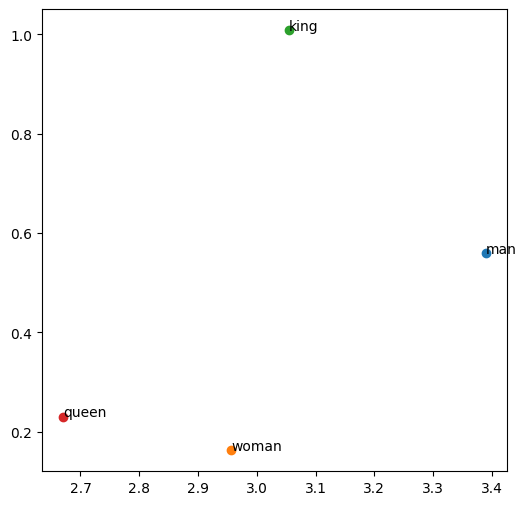

In [45]:
words = ['man', 'woman', 'king', 'queen']
# words2 = ['earth', 'moon', 'mars', 'jupiter', 'saturn', 'sun']

plt.figure(figsize=(6, 6))
for i, word in enumerate(words):
    plt.scatter(vectors_2d[wv_from_bin.key_to_index[word], 0], 
                vectors_2d[wv_from_bin.key_to_index[word], 1])
    plt.text(vectors_2d[wv_from_bin.key_to_index[word], 0], 
             vectors_2d[wv_from_bin.key_to_index[word], 1], words[i])
plt.show()